In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_attention



[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


/Users/teshima/lecture-supplement-material/Introduction-to-AI/.venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
AlbertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the eager attention implementation, but specifying the eager implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.
AlbertSdpaAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `pos


Initial Token Embeddings (first 3 and last 2 dimensions):

Token: [CLS]
Embedding: ['-0.020596147' '0.007891997' '0.02363562' '...' '-0.004295174'
 '-0.012460095']

Token: ▁i
Embedding: ['0.028208688' '0.004601662' '-0.018245349' '...' '0.018204534'
 '0.007563061']

Token: ▁went
Embedding: ['0.01354628' '0.0162569' '-0.026071826' '...' '0.02244246' '-0.03173654']

Token: ▁to
Embedding: ['-0.02254386' '0.0063173273' '-0.013336593' '...' '-0.012081529'
 '-0.011654501']

Token: ▁the
Embedding: ['0.00862282' '0.010580861' '0.012361534' '...' '0.0037768981'
 '0.013676412']

Token: ▁bank
Embedding: ['0.052289832' '-0.00073152495' '-0.0031340742' '...' '-0.0036813614'
 '0.0091330195']

Token: .
Embedding: ['-0.006049548' '-0.0377479' '-0.054646224' '...' '-0.056088414'
 '0.060904']

Token: [SEP]
Embedding: ['0.029750457' '-0.04817149' '-0.049117442' '...' '-0.038357943'
 '0.058005117']


Position Embeddings (first 3 and last 2 dimensions):

Token: [CLS]
Embedding: ['-0.03647215' '0.02234782'

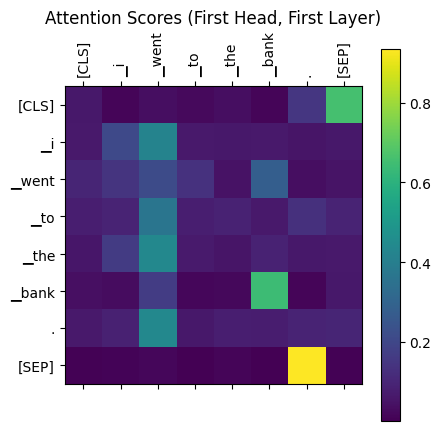


First Value Vectors (from the hidden states) (first 3 and last 2 dimensions):

Token: [CLS]
Embedding: ['-0.24021146' '0.6139428' '1.5316657' '...' '-0.0633365' '-0.36441144']

Token: ▁i
Embedding: ['-0.039578065' '-0.19113928' '-0.45048016' '...' '0.63286865' '1.2213354']

Token: ▁went
Embedding: ['0.5803583' '-0.99639434' '-1.4534172' '...' '-0.80719614' '0.7042278']

Token: ▁to
Embedding: ['-0.4659363' '0.18105817' '-0.64455616' '...' '0.5223129' '0.2738282']

Token: ▁the
Embedding: ['-0.11091763' '0.6065946' '0.47747707' '...' '-0.6650163' '0.8895689']

Token: ▁bank
Embedding: ['-1.4110688' '-0.2585587' '0.37262934' '...' '0.2159335' '0.83850515']

Token: .
Embedding: ['0.14822732' '0.6311629' '0.7105708' '...' '0.3857313' '-0.51866245']

Token: [SEP]
Embedding: ['0.010188654' '-0.5604424' '0.61950487' '...' '0.74895585' '-1.3794748']



In [7]:
# Install necessary libraries
!pip install transformers torch

from transformers import AlbertModel, AlbertTokenizer
import torch
import numpy as np
import matplotlib.pyplot as plt

# Load the pre-trained Albert model and tokenizer (small version)
model_name = 'albert-base-v2'  # Smaller ALBERT version (English)
tokenizer = AlbertTokenizer.from_pretrained(model_name)
model = AlbertModel.from_pretrained(model_name, output_attentions=True, output_hidden_states=True)

# Define the English sentence
sentence = "I went to the bank."

# Tokenize the sentence
inputs = tokenizer(sentence, return_tensors="pt")

# Forward pass through the model to get embeddings, hidden states, and attention weights
with torch.no_grad():
    # Get output from the embedding layer
    outputs = model(**inputs)
    input_embeddings = model.embeddings.word_embeddings(inputs['input_ids'])  # Initial token embeddings
    position_embeddings = model.embeddings.position_embeddings(torch.arange(inputs['input_ids'].size(1)))  # Position embeddings
    embedding_layer_output = model.embeddings(inputs['input_ids'])  # Combined result of the embedding layer (tokens + positions)

    # Get the first attention layer and first attention head (attention scores and value vectors)
    attentions = outputs.attentions[0]  # First layer's attention
    value_vectors = outputs.hidden_states[0]  # Value vectors come from hidden states in the first layer

# Get tokenized words for reference
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'].squeeze())

# Function to print embeddings in readable format (first 3 and last 2 dimensions)
def print_readable_embeddings(embeddings, tokens, description, num_start=3, num_end=2):
    print(f"\n{description} (first 3 and last 2 dimensions):\n")
    for i, token in enumerate(tokens):
        embedding_values = embeddings[i].numpy()
        # Get first 'num_start' and last 'num_end' values
        start_vals = embedding_values[:num_start]
        end_vals = embedding_values[-num_end:]
        # Print the token and selected embedding values
        print(f"Token: {token}")
        print(f"Embedding: {np.concatenate([start_vals, ['...'], end_vals])}\n")

# 1. Initial Token Embeddings
print_readable_embeddings(input_embeddings.squeeze(), tokens, "Initial Token Embeddings")

# 2. Position Embeddings
print_readable_embeddings(position_embeddings.squeeze(), tokens, "Position Embeddings")

# 3. Result of the Embedding Layer (Token + Position Embeddings)
print_readable_embeddings(embedding_layer_output.squeeze(), tokens, "Embedding Layer Output (Token + Position)")

# 4. First Attention Scores (Head 0 of Layer 0)
attention_head = attentions[0, 0]  # First attention head of the first attention layer
attention_matrix = attention_head.squeeze().detach().numpy()

# Plot the attention matrix for the first attention head
plt.matshow(attention_matrix, cmap='viridis')
plt.colorbar()
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.title('Attention Scores (First Head, First Layer)')
plt.show()

# 5. First Value Vectors (from the hidden states of the first layer)
print_readable_embeddings(value_vectors.squeeze(), tokens, "First Value Vectors (from the hidden states)")